# Spam Mail Classifier - Data Science Process

This notebook documents the end-to-end data science process used in the project. It covers the problem definition, dataset loading, exploratory data analysis, model loading, inference, and evaluation with the UCI SMS Spam Collection dataset.

The web application uses the Hugging Face model [`Goodmotion/spam-mail-classifier`](https://huggingface.co/Goodmotion/spam-mail-classifier) to classify text messages as `SPAM` or `NOSPAM`.




## 1. Problem Definition

The objective is to classify short text messages as:

- `SPAM`: unwanted, promotional, fraudulent, or suspicious messages.
- `NOSPAM`: legitimate messages.

The final product is a web application with three main views:

1. Exploratory data analysis of the SMS Spam Collection dataset.
2. Model evaluation results over labeled messages.
3. Interactive chat-style message classification.




## 2. Environment Setup

The notebook dependencies are listed in `notebook/requirements.txt`. This notebook is self-contained: it defines its own dataset, inference, and evaluation functions instead of importing code from `app/`.



In [123]:
# Dependencies were installed from the project terminal.
# On Windows, avoid reinstalling while this notebook kernel is running because pip can hit locked files.
INSTALL_REQUIREMENTS = False

if not INSTALL_REQUIREMENTS:
    print("Dependencies are already installed. Set INSTALL_REQUIREMENTS = True only after restarting the kernel if you need to reinstall.")
else:
    from pathlib import Path

    current_dir = Path.cwd()
    if (current_dir / "notebook" / "requirements.txt").exists():
        requirements_file = current_dir / "notebook" / "requirements.txt"
    elif (current_dir / "requirements.txt").exists() and current_dir.name == "notebook":
        requirements_file = current_dir / "requirements.txt"
    else:
        raise FileNotFoundError(
            f"Could not find notebook/requirements.txt from {current_dir}"
        )

    %pip install -r "{requirements_file}"


Dependencies are already installed. Set INSTALL_REQUIREMENTS = True only after restarting the kernel if you need to reinstall.


In [124]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "app").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)
print("Python executable:", sys.executable)


Project root: c:\Users\mavel\Downloads\GitHub\detector_spam
Python executable: c:\Users\mavel\Downloads\GitHub\detector_spam\.venv\Scripts\python.exe


In [125]:
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIR = PROJECT_ROOT / "data"
RAW_FILE = DATA_DIR / "SMSSpamCollection"
DATASET_SOURCE = str(RAW_FILE)


def ensure_dataset() -> Path:
    """Return the local UCI SMS Spam Collection dataset file."""
    if not RAW_FILE.exists():
        raise FileNotFoundError(
            f"Dataset not found at {RAW_FILE}. Place the SMSSpamCollection file in {DATA_DIR}."
        )

    return RAW_FILE


@lru_cache(maxsize=1)
def load_sms_dataset() -> pd.DataFrame:
    """Load the SMS Spam Collection as a normalized dataframe."""
    dataframe = pd.read_csv(
        ensure_dataset(),
        sep="\t",
        header=None,
        names=["label", "message"],
        encoding="utf-8",
    )
    dataframe["label"] = dataframe["label"].str.upper().replace({"HAM": "NOSPAM"})
    dataframe["message"] = dataframe["message"].astype(str)
    return dataframe


def with_text_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    featured = dataframe.copy()
    featured["characters"] = featured["message"].str.len()
    featured["words"] = featured["message"].str.split().str.len()
    return featured


def common_terms(dataframe: pd.DataFrame, limit: int = 15) -> pd.DataFrame:
    stop_words = {
        "a", "an", "and", "are", "as", "at", "be", "by", "for", "from",
        "in", "is", "it", "me", "my", "of", "on", "or", "that", "the",
        "to", "u", "ur", "with", "you", "your",
    }
    terms = (
        dataframe["message"]
        .str.lower()
        .str.replace(r"[^a-z0-9\s]", " ", regex=True)
        .str.split()
        .explode()
    )
    terms = terms[terms.str.len().gt(2) & ~terms.isin(stop_words)]
    return terms.value_counts().head(limit).rename_axis("term").reset_index(name="count")


def dataset_summary() -> dict:
    dataframe = load_sms_dataset()
    counts = dataframe["label"].value_counts().to_dict()
    enriched = with_text_features(dataframe)
    spam_count = int(counts.get("SPAM", 0))
    nospam_count = int(counts.get("NOSPAM", 0))
    return {
        "source": DATASET_SOURCE,
        "rows": int(len(dataframe)),
        "labels": {label: int(count) for label, count in counts.items()},
        "spam_rate": round(spam_count / len(dataframe), 4),
        "nospam_rate": round(nospam_count / len(dataframe), 4),
        "avg_characters": round(float(enriched["characters"].mean()), 2),
        "avg_words": round(float(enriched["words"].mean()), 2),
        "max_characters": int(enriched["characters"].max()),
    }


def dataset_profile() -> dict:
    dataframe = with_text_features(load_sms_dataset())
    label_distribution = (
        dataframe["label"]
        .value_counts()
        .rename_axis("label")
        .reset_index(name="count")
        .sort_values("label")
    )
    length_by_label = dataframe.groupby("label", as_index=False).agg(
        avg_characters=("characters", "mean"),
        median_characters=("characters", "median"),
        avg_words=("words", "mean"),
        median_words=("words", "median"),
    )
    return {
        "dataframe": dataframe,
        "label_distribution": label_distribution,
        "length_by_label": length_by_label.round(2),
        "common_terms": common_terms(dataframe, limit=15),
    }


def evaluation_sample(limit: int = 300) -> pd.DataFrame:
    dataframe = load_sms_dataset()
    limit = max(2, min(limit, len(dataframe)))
    per_label = max(1, limit // dataframe["label"].nunique())
    sample = (
        dataframe.groupby("label", group_keys=False)
        .apply(lambda group: group.sample(min(len(group), per_label), random_state=42))
        .sample(frac=1, random_state=42)
    )

    if len(sample) < limit:
        remainder = dataframe.drop(sample.index).sample(
            min(limit - len(sample), len(dataframe) - len(sample)),
            random_state=42,
        )
        sample = pd.concat([sample, remainder])

    return sample.sample(frac=1, random_state=42).head(limit).reset_index(drop=True)


sns.set_theme(style="whitegrid")
print("Dataset file:", RAW_FILE)


Dataset file: c:\Users\mavel\Downloads\GitHub\detector_spam\data\SMSSpamCollection


## 3. Dataset Loading

The project uses the local UCI SMS Spam Collection dataset stored at `data/SMSSpamCollection`. The helper function `load_sms_dataset()` reads that file and normalizes the original labels:

- `ham` -> `NOSPAM`
- `spam` -> `SPAM`




In [126]:
df = load_sms_dataset()
df.head()


,label,message
0,NOSPAM,"Go until jurong point, crazy.. Available only ..."
1,NOSPAM,Ok lar... Joking wif u oni...
2,SPAM,Free entry in 2 a wkly comp to win FA Cup fina...
3,NOSPAM,U dun say so early hor... U c already then say...
4,NOSPAM,"Nah I don't think he goes to usf, he lives aro..."


In [127]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


## 4. Exploratory Data Analysis

This section computes descriptive statistics used by the Streamlit tab **Analisis exploratorio de datos**.




In [128]:
summary = dataset_summary()
summary


{'source': 'c:\\Users\\mavel\\Downloads\\GitHub\\detector_spam\\data\\SMSSpamCollection',
 'rows': 5572,
 'labels': {'NOSPAM': 4825, 'SPAM': 747},
 'spam_rate': 0.1341,
 'nospam_rate': 0.8659,
 'avg_characters': 80.49,
 'avg_words': 15.6,
 'max_characters': 910}

In [129]:
profile = dataset_profile()
label_distribution = profile["label_distribution"]
length_by_label = profile["length_by_label"]
common_terms = profile["common_terms"]
eda_df = profile["dataframe"]

label_distribution


,label,count
0,NOSPAM,4825
1,SPAM,747


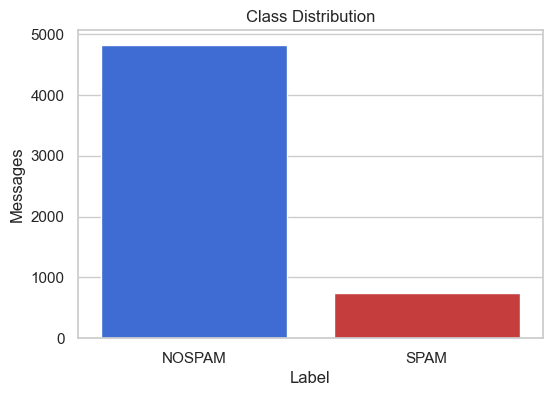

In [130]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=label_distribution,
    x="label",
    y="count",
    hue="label",
    palette={"NOSPAM": "#2563eb", "SPAM": "#dc2626"},
    legend=False,
)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Messages")
plt.show()


In [131]:
length_by_label


,label,avg_characters,median_characters,avg_words,median_words
0,NOSPAM,71.48,52.0,14.31,11.0
1,SPAM,138.67,149.0,23.91,25.0


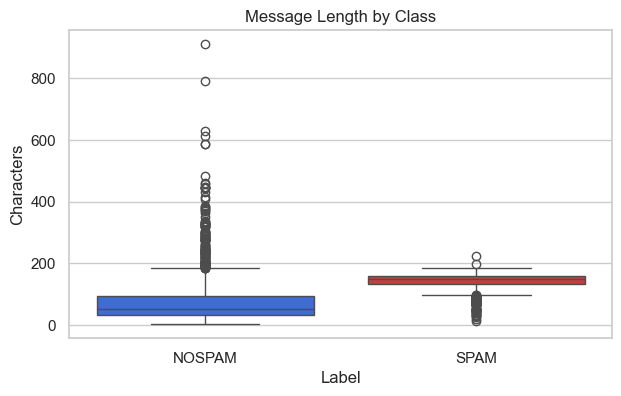

In [132]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=eda_df,
    x="label",
    y="characters",
    hue="label",
    palette={"NOSPAM": "#2563eb", "SPAM": "#dc2626"},
    legend=False,
)
plt.title("Message Length by Class")
plt.xlabel("Label")
plt.ylabel("Characters")
plt.show()


In [133]:
common_terms.head(15)


,term,count
0,call,593
1,have,578
2,now,502
3,can,471
4,but,448
5,not,445
6,get,391
7,will,390
8,just,376
9,this,343


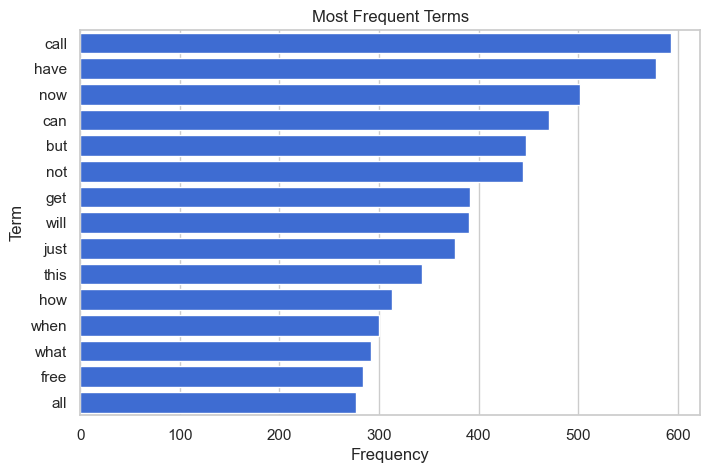

In [134]:
plt.figure(figsize=(8, 5))
sns.barplot(data=common_terms.head(15), y="term", x="count", color="#2563eb")
plt.title("Most Frequent Terms")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.show()


## 5. Text Preprocessing and Classical Baseline

This section adds a classical machine learning baseline. It checks duplicate rows, applies a lightweight text normalization pipeline, converts messages into unigram and bigram features, and trains a Multinomial Naive Bayes classifier for comparison with the transformer model.




In [135]:
duplicate_summary = pd.DataFrame(
    [
        {"check": "full duplicated rows", "count": int(df.duplicated().sum())},
        {"check": "duplicated label/message pairs", "count": int(df.duplicated(subset=["label", "message"]).sum())},
        {"check": "unique labels", "count": int(df["label"].nunique())},
    ]
)

deduplicated_df = df.drop_duplicates(subset=["label", "message"]).reset_index(drop=True)
duplicate_summary


,check,count
0,full duplicated rows,403
1,duplicated label/message pairs,403
2,unique labels,2


In [136]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


def preprocess_message(message: str) -> str:
    """Normalize SMS text for classical bag-of-words modeling."""
    normalized = str(message).lower()
    normalized = re.sub(r"[^a-z\s$!]", " ", normalized)
    tokens = [token for token in normalized.split() if token not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)


preprocessing_preview = df[["label", "message"]].head(8).copy()
preprocessing_preview["processed_message"] = preprocessing_preview["message"].apply(preprocess_message)
preprocessing_preview


,label,message,processed_message
0,NOSPAM,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,NOSPAM,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,SPAM,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,NOSPAM,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,NOSPAM,"Nah I don't think he goes to usf, he lives aro...",nah don t think goes usf lives
5,SPAM,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling s week s word back! d like...
6,NOSPAM,Even my brother is not like to speak with me. ...,brother like speak treat like aids patent
7,NOSPAM,As per your request 'Melle Melle (Oru Minnamin...,request melle melle oru minnaminunginte nurung...


In [137]:
from sklearn.feature_extraction.text import CountVectorizer

processed_df = deduplicated_df.copy()
processed_df["processed_message"] = processed_df["message"].apply(preprocess_message)
processed_df = processed_df[processed_df["processed_message"].str.len().gt(0)].reset_index(drop=True)

baseline_vectorizer = CountVectorizer(min_df=2, max_df=0.9, ngram_range=(1, 2))
baseline_matrix = baseline_vectorizer.fit_transform(processed_df["processed_message"])
term_frequencies = pd.Series(
    baseline_matrix.sum(axis=0).A1,
    index=baseline_vectorizer.get_feature_names_out(),
).sort_values(ascending=False)

pd.DataFrame(
    {
        "metric": ["messages", "features", "matrix_nonzero_values"],
        "value": [processed_df.shape[0], baseline_matrix.shape[1], baseline_matrix.nnz],
    }
)


,metric,value
0,messages,5156
1,features,6545
2,matrix_nonzero_values,44192


In [138]:
top_terms_by_class = []
for label in ["NOSPAM", "SPAM"]:
    class_messages = processed_df.loc[processed_df["label"].eq(label), "processed_message"]
    class_matrix = baseline_vectorizer.transform(class_messages)
    class_terms = pd.Series(
        class_matrix.sum(axis=0).A1,
        index=baseline_vectorizer.get_feature_names_out(),
    ).sort_values(ascending=False).head(15)
    top_terms_by_class.append(
        pd.DataFrame({"label": label, "term": class_terms.index, "count": class_terms.values})
    )

top_terms_by_class = pd.concat(top_terms_by_class, ignore_index=True)
top_terms_by_class


,label,term,count
0,NOSPAM,gt,288
1,NOSPAM,lt,287
2,NOSPAM,just,282
3,NOSPAM,ok,256
4,NOSPAM,lt gt,254
5,NOSPAM,ll,233
6,NOSPAM,got,228
7,NOSPAM,know,226
8,NOSPAM,like,224
9,NOSPAM,good,217


In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    processed_df["processed_message"],
    processed_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=processed_df["label"],
)

baseline_pipeline = Pipeline(
    steps=[
        ("vectorizer", CountVectorizer(min_df=2, max_df=0.9, ngram_range=(1, 2))),
        ("classifier", MultinomialNB()),
    ]
)

baseline_search = GridSearchCV(
    baseline_pipeline,
    param_grid={"classifier__alpha": [0.01, 0.1, 0.25, 0.5, 0.75, 1.0]},
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
)
baseline_search.fit(X_train, y_train)

baseline_predictions = baseline_search.predict(X_test)
baseline_metrics = {
    "best_alpha": baseline_search.best_params_["classifier__alpha"],
    "cv_f1_macro": round(float(baseline_search.best_score_), 4),
    "test_accuracy": round(float(accuracy_score(y_test, baseline_predictions)), 4),
}
baseline_metrics


In [ ]:
baseline_report = pd.DataFrame(
    classification_report(
        y_test,
        baseline_predictions,
        labels=["NOSPAM", "SPAM"],
        output_dict=True,
        zero_division=0,
    )
).transpose()
baseline_report


,precision,recall,f1-score,support
NOSPAM,0.990066,0.995560,0.992806,901.000000
SPAM,0.968254,0.931298,0.949416,131.000000
accuracy,0.987403,0.987403,0.987403,0.987403
macro avg,0.979160,0.963429,0.971111,1032.000000
weighted avg,0.987297,0.987403,0.987298,1032.000000


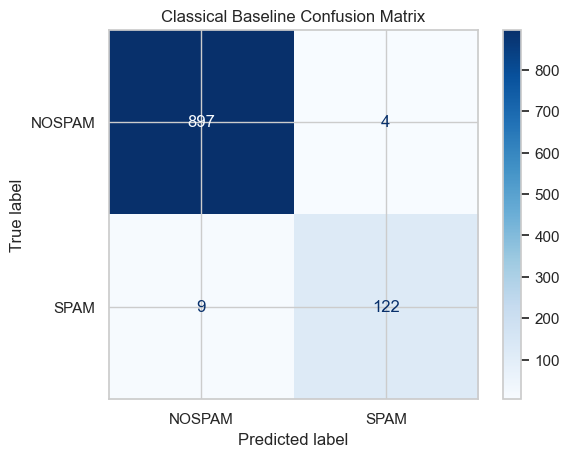

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    labels=["NOSPAM", "SPAM"],
    cmap="Blues",
)
plt.title("Classical Baseline Confusion Matrix")
plt.show()


In [ ]:
baseline_examples = [
    "Congratulations! You've won a $1000 gift card. Claim now!",
    "Hey, are we still meeting for lunch today?",
    "Urgent! Your account has been hacked, verify immediately.",
    "Please review the meeting notes when you have time.",
]

processed_examples = [preprocess_message(message) for message in baseline_examples]
baseline_example_predictions = baseline_search.predict(processed_examples)
baseline_example_probabilities = baseline_search.predict_proba(processed_examples)
baseline_classes = baseline_search.best_estimator_.named_steps["classifier"].classes_

pd.DataFrame(
    [
        {
            "message": message,
            "processed_message": processed,
            "prediction": prediction,
            "spam_probability": round(float(probabilities[list(baseline_classes).index("SPAM")]), 4),
            "nospam_probability": round(float(probabilities[list(baseline_classes).index("NOSPAM")]), 4),
        }
        for message, processed, prediction, probabilities in zip(
            baseline_examples,
            processed_examples,
            baseline_example_predictions,
            baseline_example_probabilities,
        )
    ]
)


,message,processed_message,prediction,spam_probability,nospam_probability
0,Congratulations! You've won a $1000 gift card....,congratulations! ve won $ gift card claim now!,SPAM,1.0000,0.0000
1,"Hey, are we still meeting for lunch today?",hey meeting lunch today,NOSPAM,0.0000,1.0000
2,"Urgent! Your account has been hacked, verify i...",urgent! account hacked verify immediately,SPAM,0.9979,0.0021
3,Please review the meeting notes when you have ...,review meeting notes time,NOSPAM,0.0041,0.9959


## 6. Saving and Loading the Classical Model

The trained classical baseline is saved with `joblib` so it can be reused without retraining. The saved artifact contains the fitted vectorizer and classifier pipeline.



In [ ]:
import joblib

MODEL_ARTIFACT_DIR = PROJECT_ROOT / "models"
MODEL_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_FILENAME = MODEL_ARTIFACT_DIR / "spam_detection_baseline.joblib"

joblib.dump(baseline_search.best_estimator_, MODEL_FILENAME)
print(f"Model saved to {MODEL_FILENAME}")


In [ ]:
loaded_baseline_model = joblib.load(MODEL_FILENAME)
loaded_baseline_model.predict([preprocess_message("Urgent! my account has been hacked!")])


## 7. Single Message Classification

This section uses the trained classical baseline to classify individual messages. The same preprocessing function used during training is applied before prediction, so the input format is consistent between training and inference.



In [ ]:
LABELS = ["NOSPAM", "SPAM"]


def classify_texts(texts):
    """Classify one or more texts with the trained classical baseline."""
    clean_texts = [str(text).strip() for text in texts if text and str(text).strip()]
    if not clean_texts:
        return []

    processed_texts = [preprocess_message(text) for text in clean_texts]
    predictions = baseline_search.predict(processed_texts)
    probabilities = baseline_search.predict_proba(processed_texts)
    classes = list(baseline_search.best_estimator_.named_steps["classifier"].classes_)

    results = []
    for text, processed_text, prediction, probability in zip(
        clean_texts,
        processed_texts,
        predictions,
        probabilities,
    ):
        scores = {label: round(float(probability[classes.index(label)]), 4) for label in classes}
        confidence = scores[prediction]
        results.append(
            {
                "text": text,
                "processed_text": processed_text,
                "label": prediction,
                "confidence": confidence,
                "scores": scores,
            }
        )

    return results


def classify_text(text: str):
    results = classify_texts([text])
    return results[0] if results else None


print("Classifier: CountVectorizer + MultinomialNB baseline")


Classifier: CountVectorizer + MultinomialNB baseline


In [ ]:
classify_text("Urgent: Verify your account immediately.")


{'text': 'Urgent: Verify your account immediately.',
 'processed_text': 'urgent verify account immediately',
 'label': 'SPAM',
 'confidence': 0.9979,
 'scores': {'NOSPAM': 0.0021, 'SPAM': 0.9979}}

In [ ]:
examples = [
    "Join us for a webinar on AI innovations",
    "Urgent: Verify your account immediately.",
    "Meeting rescheduled to 3 PM",
    "Claim your free prize now!",
]

pd.DataFrame(classify_texts(examples))


,text,processed_text,label,confidence,scores
0,Join us for a webinar on AI innovations,join webinar ai innovations,NOSPAM,0.6104,"{'NOSPAM': 0.6104, 'SPAM': 0.3896}"
1,Urgent: Verify your account immediately.,urgent verify account immediately,SPAM,0.9979,"{'NOSPAM': 0.0021, 'SPAM': 0.9979}"
2,Meeting rescheduled to 3 PM,meeting rescheduled pm,NOSPAM,0.9887,"{'NOSPAM': 0.9887, 'SPAM': 0.0113}"
3,Claim your free prize now!,claim free prize now!,SPAM,1.0000,"{'NOSPAM': 0.0, 'SPAM': 1.0}"


## 8. Model Evaluation on the Dataset

The evaluation uses a deterministic stratified sample from the dataset. This keeps the evaluation fast while ensuring both classes are represented. The notebook-defined `evaluate_messages()` function computes accuracy, classification metrics, predictions, and the confusion matrix for the classical baseline.



In [ ]:
eval_df = evaluation_sample(100)
eval_df["label"].value_counts()


C:\Users\mavel\AppData\Local\Temp\ipykernel_2952\629417075.py:109: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(min(len(group), per_label), random_state=42))


label
NOSPAM    50
SPAM      50
Name: count, dtype: int64

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def evaluate_messages(dataframe: pd.DataFrame) -> dict:
    if dataframe.empty:
        return {
            "accuracy": 0.0,
            "count": 0,
            "confusion_matrix": [],
            "classification_report": {},
            "predictions": [],
        }

    predictions = classify_texts(dataframe["message"].astype(str).tolist())
    y_true = dataframe["label"].astype(str).str.upper().tolist()
    y_pred = [item["label"] for item in predictions]

    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "count": len(y_true),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=LABELS).tolist(),
        "classification_report": classification_report(
            y_true,
            y_pred,
            labels=LABELS,
            output_dict=True,
            zero_division=0,
        ),
        "predictions": predictions,
    }


evaluation = evaluate_messages(eval_df)
print("Messages evaluated:", evaluation["count"])
print("Accuracy:", evaluation["accuracy"])
evaluation["confusion_matrix"]


Messages evaluated: 100
Accuracy: 0.98


[[49, 1], [1, 49]]

In [ ]:
report = pd.DataFrame(evaluation["classification_report"]).transpose()
report


,precision,recall,f1-score,support
NOSPAM,0.98,0.98,0.98,50.00
SPAM,0.98,0.98,0.98,50.00
accuracy,0.98,0.98,0.98,0.98
macro avg,0.98,0.98,0.98,100.00
weighted avg,0.98,0.98,0.98,100.00


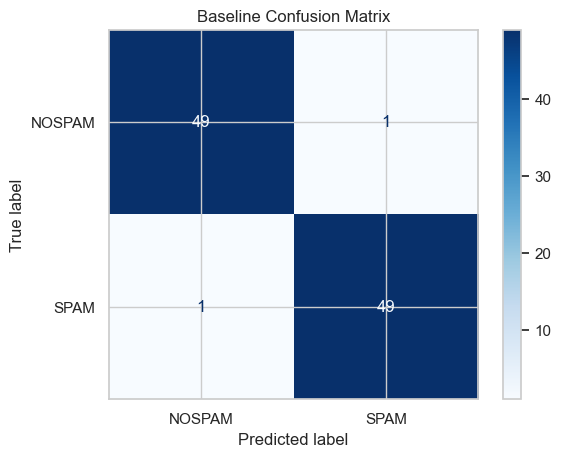

In [ ]:
import numpy as np

ConfusionMatrixDisplay(
    confusion_matrix=np.array(evaluation["confusion_matrix"]),
    display_labels=LABELS,
).plot(cmap="Blues")
plt.title("Baseline Confusion Matrix")
plt.show()


In [ ]:
prediction_rows = []
for row, prediction in zip(eval_df.to_dict(orient="records"), evaluation["predictions"]):
    prediction_rows.append({
        "label_real": row["label"],
        "label_predicha": prediction["label"],
        "correcta": row["label"] == prediction["label"],
        "confianza": prediction["confidence"],
        "message": row["message"],
    })

predictions_df = pd.DataFrame(prediction_rows)
predictions_df.head(10)


,label_real,label_predicha,correcta,confianza,message
0,NOSPAM,NOSPAM,True,1.0000,Yeah he got in at 2 and was v apologetic. n ha...
1,NOSPAM,NOSPAM,True,1.0000,She left it very vague. She just said she woul...
2,SPAM,SPAM,True,1.0000,"Eerie Nokia tones 4u, rply TONE TITLE to 8007 ..."
3,NOSPAM,NOSPAM,True,0.9991,Baaaaabe! I misss youuuuu ! Where are you ? I ...
4,NOSPAM,NOSPAM,True,0.9982,i want to grasp your pretty booty :)
5,NOSPAM,NOSPAM,True,1.0000,K ill drink.pa then what doing. I need srs mod...
6,NOSPAM,NOSPAM,True,0.8734,Mathews or tait or edwards or anderson
7,SPAM,SPAM,True,1.0000,pdate_Now - Double mins and 1000 txts on Orang...
8,NOSPAM,NOSPAM,True,1.0000,"YEH I AM DEF UP4 SOMETHING SAT,JUST GOT PAYED2..."
9,SPAM,SPAM,True,1.0000,Hi 07734396839 IBH Customer Loyalty Offer: The...


In [ ]:
correct_examples = predictions_df[predictions_df["correcta"]].head(5)
incorrect_examples = predictions_df[~predictions_df["correcta"]].head(5)

correct_examples, incorrect_examples


(  label_real label_predicha  correcta  confianza  \
 0     NOSPAM         NOSPAM      True     1.0000   
 1     NOSPAM         NOSPAM      True     1.0000   
 2       SPAM           SPAM      True     1.0000   
 3     NOSPAM         NOSPAM      True     0.9991   
 4     NOSPAM         NOSPAM      True     0.9982   
 
                                              message  
 0  Yeah he got in at 2 and was v apologetic. n ha...  
 1  She left it very vague. She just said she woul...  
 2  Eerie Nokia tones 4u, rply TONE TITLE to 8007 ...  
 3  Baaaaabe! I misss youuuuu ! Where are you ? I ...  
 4               i want to grasp your pretty booty :)  ,
    label_real label_predicha  correcta  confianza  \
 35     NOSPAM           SPAM     False     0.9668   
 50       SPAM         NOSPAM     False     0.7297   
 
                                               message  
 35                             Nokia phone is lovly..  
 50  ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...  )

## 9. Web Application Implementation

The production code is organized in the `app/` folder:

- `app/data.py`: loads, normalizes, summarizes, profiles, and samples the local UCI dataset from `data/SMSSpamCollection`.
- `app/model.py`: loads the Hugging Face model, classifies messages, and evaluates predictions with scikit-learn metrics.
- `app/streamlit_app.py`: implements the three required tabs: EDA, model evaluation, and chat-style classification.
- `app/fastapi_app.py`: exposes API endpoints for health checks, single prediction, batch prediction, and dataset summary.

This notebook is independent from `app/`. The application can be read as a separate implementation that operationalizes the workflow demonstrated here.




## 10. Conclusions

The project integrates the local UCI SMS Spam Collection dataset with two complementary modeling paths: a classical bag-of-words baseline and a pretrained Hugging Face spam classifier. The notebook validates the data pipeline, duplicate handling, exploratory analysis, text preprocessing, feature extraction, baseline metrics, transformer inference workflow, and evaluation metrics before exposing the functionality in the web app.

The Streamlit application operationalizes the workflow by providing:

1. Descriptive dataset analysis.
2. Evaluation metrics and prediction examples.
3. Interactive message classification.

